**Day-9 MiniProject**

1.   Load CSV into SQLite
2.   Get DB Schema
3.   Generate SQL with Groq
4.   Execute SQL in SQLite
5.   Natural Language Geneation


**Day-9 MiniProject**

1.   Accept User Question in plain English
2.   Generate SQL query automatically with Groq
3.   Execute SQL query in SQLite student_performance DB
4.   Display result as a Table
5.   Render a barchart using Matplotlib




In [ ]:
!pip install groq chromadb -q
print("Installation Completed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currentl

In [ ]:
import pandas as pd
import sqlite3
import chromadb
from sentence_transformers import SentenceTransformer
from groq import Groq
import os
import re
import io
from google.colab import userdata

print("All Libraries imported successfully")

All Libraries imported successfully


In [ ]:
GROQ_API_KEY = userdata.get('GROQ_API_KEY')
os.environ['GROQ_API_KEY'] = GROQ_API_KEY

groq_client = Groq(api_key=GROQ_API_KEY)
print("Groq API client Initiated")

Groq API client Initiated


In [ ]:
df = pd.read_csv("student_performance.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
display(df)

Shape: (30, 13)
Columns: ['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023
5,1006,Meera Joshi,20,Female,Electronics,2,58,66,70,52,72,Pune,2023
6,1007,Kiran Kumar,21,Male,Civil,2,73,69,65,40,85,Bangalore,2023
7,1008,Divya Singh,19,Female,Computer Science,2,88,91,84,93,96,Lucknow,2023
8,1009,Rahul Mishra,20,Male,Mechanical,2,62,71,58,45,68,Varanasi,2023
9,1010,Ananya Das,19,Female,Computer Science,2,95,89,90,97,98,Kolkata,2023


In [ ]:
MODEL = 'llama-3.1-8b-instant'
print(f"Model: {MODEL}")

Model: llama-3.1-8b-instant


In [ ]:
conn = sqlite3.connect("college.db")
df.to_sql("students", conn, if_exists="replace", index=False)

test_df = pd.read_sql_query("SELECT COUNT(*) as total_rows FROM students", conn)
print(f"\nVerification: {test_df['total_rows'][0]} rows in database")


Verification: 30 rows in database


In [ ]:
def get_schema(conn=conn, table_name="students"):
  cursor = conn.cursor()
  cursor.execute(f"PRAGMA table_info({table_name})")
  columns = cursor.fetchall()

  schema_lines = [f"Table: {table_name}"]
  schema_lines.append("Columns:")
  for col in columns:
    schema_lines.append(f"  - {col[1]} ({col[2]})")

  cursor.execute(f"SELECT * FROM {table_name} LIMIT 3")
  sample_rows = cursor.fetchall()
  schema_lines.append("\nSample rows (first 3):")

  for row in sample_rows:
    schema_lines.append(f"  {row}")

  return "\n".join(schema_lines)

schema = get_schema()
print(schema)

Table: students
Columns:
  - student_id (INTEGER)
  - name (TEXT)
  - age (INTEGER)
  - gender (TEXT)
  - department (TEXT)
  - semester (INTEGER)
  - math_score (INTEGER)
  - science_score (INTEGER)
  - english_score (INTEGER)
  - programming_score (INTEGER)
  - attendance_percentage (INTEGER)
  - city (TEXT)
  - admission_year (INTEGER)

Sample rows (first 3):
  (1001, 'Aarav Sharma', 19, 'Male', 'Computer Science', 2, 85, 78, 72, 91, 92, 'Mumbai', 2023)
  (1002, 'Priya Patel', 20, 'Female', 'Computer Science', 2, 76, 82, 88, 79, 87, 'Ahmedabad', 2023)
  (1003, 'Rohit Verma', 19, 'Male', 'Electronics', 2, 65, 74, 61, 55, 78, 'Delhi', 2023)


In [ ]:
def generate_sql(user_question, schema_text, client, model):
  system_prompt = f""" You are an expert SQL asistant.
  You are connected to a SQLite Database with the following schema:
  {schema_text}

  Rules you must follow:
  1. Generate ONLY a valid SQLite SQL query.
  2. Do not include any explanation or text — only the SQL query.
  3. Do not use markdown code blocks. Return the raw SQL only.
  4. The table name is: students
  5. Only use column names that exist in the schema above.
  6. Use single quotes for string values in WHERE clauses (example: WHERE subject = 'Programming').
  7. If the user asks for top N, use ORDER BY marks DESC LIMIT N.
  """
  response = client.chat.completions.create(
    model=model,
    messages=[
      {"role": "system", "content": system_prompt},
      {"role": "user", "content": user_question}
    ],
    temperature=0.0
  )
  sql_response = response.choices[0].message.content.strip()
  return sql_response

question = "Who the Top 5 students with highest marks in programming?"
print(f"Question: {question}")
print("\nGenerating SQL Query...")
sql = generate_sql(question, schema, groq_client, MODEL)
print(f"Generated SQL:\n{sql}")

Question: Who the Top 5 students with highest marks in programming?

Generating SQL Query...
Generated SQL:
SELECT name, programming_score FROM students ORDER BY programming_score DESC LIMIT 5


In [ ]:
def execute_sql(sql_query,conn=conn):
    clean_sql = sql_query.strip()
    clean_sql = re.sub(r'\s+', ' ', clean_sql)
    clean_sql = clean_sql.strip()
    try:
        result_df = pd.read_sql_query(clean_sql, conn)
        return result_df,None
    except Exception as e:
        return None, str(e)

print(f"Executing SQL: {sql}")
result, error = execute_sql(sql)

if error:
  print(f"Error: {error}")
else:
  print(f"\nQuery returned {len(result)} rows:")
  print(result)

Executing SQL: SELECT name, programming_score FROM students ORDER BY programming_score DESC LIMIT 5

Query returned 5 rows:
             name  programming_score
0      Ananya Das                 97
1     Tanvi Mehta                 96
2      Arjun Nair                 95
3  Akanksha Yadav                 94
4     Divya Singh                 93


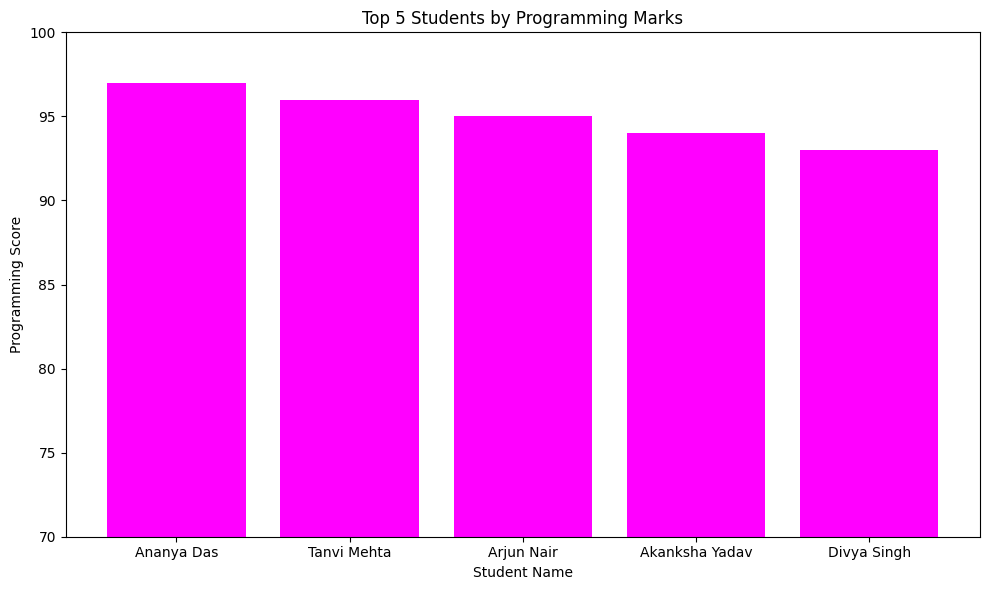

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(result['name'], result['programming_score'], color='magenta')
plt.xlabel('Student Name')
plt.ylabel('Programming Score') # Changed label
plt.title('Top 5 Students by Programming Marks')
plt.ylim(70, 100) # Adjusted y-axis limits
plt.tight_layout()
plt.show()

In [ ]:
def generate_answer(user_question, result_df, client=groq_client, model=MODEL):
  if result_df is not None and not result_df.empty:
    result_text = result_df.to_string(index=False)
  else:
    result_text = "No results found."

  prompt = f"""
  You are asked {user_question}
  The database returned these results:
  {result_text}

  Please write a very friendly, 2-3 line answer to the user's question based on the response. Be specific.
  Mention the actual names and numbers in the data.
  Do not add extra information.
  """

  response = client.chat.completions.create(
      model=model,
      messages=[
        {"role": "user", "content": prompt}
      ],
      temperature=0.4
  )
  return response.choices[0].message.content.strip()

In [ ]:
def text_to_sql_agent(user_question,conn=conn, client=groq_client, model=MODEL, verbose=True):
  print("="*80)
  print(f"Question: {user_question}")
  print("="*80)

  schema_text = get_schema(conn)

  if verbose:
    print("\nGenerating SQL query...")
  generated_sql = generate_sql(user_question, schema_text, client, model)
  print(f"{generated_sql}")
  result_df, error = execute_sql(generated_sql,conn)

  if error:
    print(f"SQL Execution Error: {error}")
    return None, generated_sql, None

  if verbose:
    print(f"\nQuery returned {len(result_df)} rows:")
    print("="*40)
    print(result_df.to_string(index=False))

  print("\nGenerating Natural Language Answer...")
  # Now passing result_df directly to generate_answer to prevent recursion
  nl_answer = generate_answer(user_question, result_df, groq_client, MODEL)
  print("\nNatural Language Answer:")
  print(nl_answer)

  print("="*40)
  return result_df, generated_sql, nl_answer

result, sql_used, nl_answer_result = text_to_sql_agent("Who the Top 5 students with highest marks in programming?")

Question: Who the Top 5 students with highest marks in programming?

Generating SQL query...
SELECT name, programming_score FROM students ORDER BY programming_score DESC LIMIT 5

Query returned 5 rows:
          name  programming_score
    Ananya Das                 97
   Tanvi Mehta                 96
    Arjun Nair                 95
Akanksha Yadav                 94
   Divya Singh                 93

Generating Natural Language Answer...

Natural Language Answer:
Based on the results, the top 5 students with the highest marks in programming are: Ananya Das with 97, Tanvi Mehta with 96, Arjun Nair with 95, Akanksha Yadav with 94, and Divya Singh with 93.
